# MIL pooling sweep on frozen exp05 mu

Each star is a **bag** of window-level mu vectors, and the star-level probe score depends entirely on how that bag is aggregated. This notebook compares every pooling operator in `swm.eval.pooling` on the frozen exp05 encoder, declaring the winner per task on the val split and reporting it on test.

Numbers come from `swm.eval.mil_sweep` (long tables) and `swm.eval.mil_report` (derived blocks); this notebook only reads and plots. Plan: `docs/plans/2026-07-25-mil-pooling-sweep.md`, writeup `experiments/mil_pooling/README.md`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mil_dir = Path.cwd().parents[1] / "experiments" / "mil_pooling"
headline_cell = "exp05_comb_fbwd_c1p0"


def load_pool(pool):
    pattern = "mil_sweep.csv" if pool == "v1" else "mil_sweep_new_task*.csv"
    parts = []
    for path in sorted(mil_dir.glob(pattern)):
        parts.append(pd.read_csv(path))
    if pool == "v1":
        learned = pd.read_csv(mil_dir / "mil_learned.csv")
        learned["kmatch"] = 0
        parts.append(learned)
    frame = pd.concat(parts, ignore_index=True)
    frame["param"] = frame["param"].fillna(-1.0)
    frame["kmatch"] = frame["kmatch"].fillna(0).astype(int)
    if "metric" not in frame.columns:
        frame["metric"] = "pr_auc"
    frame["metric"] = frame["metric"].fillna("pr_auc")
    for generic, legacy in [("score_val", "pr_auc_val"), ("score_test", "pr_auc_test")]:
        if generic not in frame.columns:
            frame[generic] = np.nan
        frame[generic] = frame[generic].fillna(frame[legacy])
    frame["bag_arm"] = np.where(frame.kmatch > 0, "kmatch16", frame.bag_scope)
    return frame


results = pd.read_csv(mil_dir / "mil_pooling_results.csv")
results_nt = pd.read_csv(mil_dir / "mil_pooling_results_new_task.csv")
sweep = load_pool("v1")
sweep_nt = load_pool("new_task")
sweep.groupby(["bag_arm", "arm_kind"]).size()

bag_arm   arm_kind 
all       trained      1344
          untrained     168
first     trained      1408
          untrained     180
kmatch16  trained      3072
          untrained     384
dtype: int64

### What just loaded

`sweep` is the raw long table: one row per operator, hyperparameter, task, encoder arm and seed. `results` is the small derived table of headline numbers. The `_nt` versions are the separate downstream star pool.

Vocabulary used everywhere below:

- **`arm_kind`**: `trained` is the self-supervised encoder, `untrained` is the same architecture with random weights. The random one is the baseline the trained one has to beat.
- **`block`** (in `results`): which derived table a row belongs to, one of `winner`, `witness_rate`, `control`, `kmatch`, `tier3`.
- **`family`**: how an operator works. **`feature`** combines the mu vectors first, then runs one classifier on the combined vector. **`score`** runs the classifier on every window first, then combines the per-window scores. **`learned`** trains a small neural pooling network, which is why it is reported as a diagnostic only.
- **`metric`**: `pr_auc` for yes/no detection tasks, `r2` for tasks that predict a number. `score_val` and `score_test` hold whichever metric applies, so both kinds of task share one table.

In [2]:
sweep.groupby("bag_arm")[["mean_bag_size"]].mean()

,mean_bag_size
bag_arm,
all,61.563582
first,16.197922
kmatch16,16.000000


### Bag arms, and what `mean_bag_size` means

**`mean_bag_size`** is just the average number of windows per star under that arm. One window is 256 cadences, about 8.5 hours.

- **`first`**: only the star's first packed segment, about 16 windows or 5.7 days. Every result through exp05 used this, which means roughly 74 percent of available windows were being discarded.
- **`all`**: every packed window the star has. Median 32, mean 62, maximum 816.
- **`kmatch16`**: 16 windows drawn at random from across *all* segments. Bag size is forced back to 16 while the time span stays wide.

Why `kmatch16` exists: comparing `first` against `all` is unfair, because some operators score higher simply from being handed more windows. Holding the count fixed separates "the signal is easier to see over a longer baseline" from "more windows is just more chances".

In [3]:
winners = results[results.block == "winner"].dropna(axis=1, how="all")
winners.sort_values(["task", "bag_arm"])[["task", "bag_arm", "pooling", "param", "score_test",
                                          "untrained_test", "gap", "two_se", "confirmed",
                                          "mean_pool_test", "gain_over_mean"]]

,task,bag_arm,pooling,param,score_test,untrained_test,gap,two_se,confirmed,mean_pool_test,gain_over_mean
11,eb,all,moments,-1.00,0.808824,0.734661,0.074162,0.011779,True,0.783944,0.024880
7,eb,first,moments,-1.00,0.763364,0.719603,0.043761,0.007013,True,0.763795,-0.000431
6,eb,kmatch16,moments,-1.00,0.744031,0.712189,0.031843,0.006386,True,0.741397,0.002634
10,pulsating,all,moments,-1.00,0.819145,0.783213,0.035931,0.014733,True,0.807723,0.011422
8,pulsating,first,ws_topk,1.00,0.772275,0.740877,0.031398,0.015530,True,0.803703,-0.031428
9,pulsating,kmatch16,ws_ppv_lspv,0.75,0.803988,0.768146,0.035841,0.004419,True,0.802025,0.001963
5,rotation,all,ws_ppv_lspv,0.95,0.561375,0.542306,0.019069,0.008075,True,0.568554,-0.007179
4,rotation,first,ws_ppv_lspv,0.95,0.557481,0.525154,0.032327,0.019342,True,0.557953,-0.000472
3,rotation,kmatch16,ws_ppv_lspv,0.95,0.549527,0.523018,0.026509,0.007827,True,0.549633,-0.000106
2,transit,all,moments,-1.00,0.353773,0.200862,0.152911,0.011961,True,0.174189,0.179584


### The headline table: best operator per task, chosen on val, reported on test

- **`score_test`**: the trained encoder's score on held-out test stars. Higher is better.
- **`untrained_test`**: the same operator applied to a random-weight encoder.
- **`gap`** = `score_test` minus `untrained_test`. This answers "did pretraining help?".
- **`two_se`**: twice the standard error of that gap across the 4 seeds, so it is the noise floor.
- **`confirmed`**: True when `gap` is bigger than `two_se`, meaning the improvement beats seed-to-seed noise.
- **`mean_pool_test`**: what plain mean pooling scores, the protocol every earlier result used.
- **`gain_over_mean`** = `score_test` minus `mean_pool_test`. This is what the whole study bought.

Read the transit rows first: mean pooling scores 0.145 and the winning operator reaches 0.21 to 0.24, with no retraining at all. On eb, pulsating and rotation `gain_over_mean` sits near zero, which is itself the result: pooling is a lever for localized signals, not a universal one.

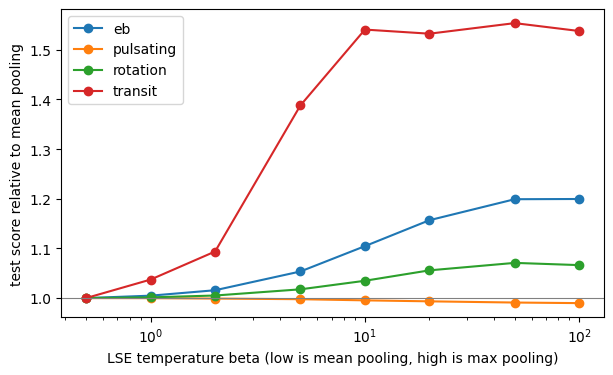

In [4]:
lse = sweep[(sweep.arm_kind == "trained") & (sweep.exp_name == headline_cell)
            & (sweep.pooling == "ws_lse") & (sweep.bag_arm == "first")]
curve = lse.groupby(["task", "param"])["score_test"].mean().reset_index()
plt.figure(figsize=(7, 4))
for task, group in curve.groupby("task"):
    group = group.sort_values("param")
    plt.plot(group.param, group.score_test / group.score_test.iloc[0], marker="o", label=task)
plt.xscale("log")
plt.axhline(1.0, color="grey", linewidth=0.8)
plt.xlabel("LSE temperature beta (low is mean pooling, high is max pooling)")
plt.ylabel("test score relative to mean pooling")
plt.legend()
plt.show()

### Reading the plot

`ws_lse` is a single operator with one dial, **beta**, that slides smoothly from mean pooling on the left to max pooling on the right. Mean pooling averages every window equally. Max pooling listens only to the single loudest window. Everything in between is a soft blend.

Each curve is divided by its own left-hand value, so 1.0 means "same as mean pooling".

A curve that **rises** means the signal lives in a few windows, so letting one loud window dominate helps. A curve that **falls** means the signal is spread across all windows, so averaging was already correct and max pooling is throwing information away. Transit rises steeply; pulsating drifts below 1.0.

In [5]:
witness = results[results.block == "witness_rate"].dropna(axis=1, how="all")
witness[witness.bag_arm == "first"].sort_values("rel_gain_mean_to_max", ascending=False)

,block,task,bag_arm,pr_auc_test,pr_auc_test_beta_min,pr_auc_test_beta_max,beta_star_test,rel_gain_mean_to_max
19,witness_rate,transit,first,0.181808,0.117006,0.179945,50.0,0.537908
16,witness_rate,eb,first,0.731123,0.609481,0.731123,100.0,0.199583
18,witness_rate,rotation,first,0.569013,0.531347,0.566627,50.0,0.066398
17,witness_rate,pulsating,first,0.782369,0.782369,0.774422,0.5,-0.010158


### The same plot as numbers, and what "witness rate" means

The **witness rate** is the fraction of a star's windows that actually contain the signal. A transit occupies maybe one or two windows out of sixteen. A pulsation occupies all sixteen. In the MIL literature the low case is the "standard assumption" and the high case the "collective assumption", and they want opposite operators.

- **`pr_auc_test_beta_min`**: score at the lowest beta tested, so effectively mean pooling.
- **`pr_auc_test_beta_max`**: score at the highest beta tested, so effectively max pooling.
- **`beta_star_test`**: the beta value that scored best. Bigger means a more localized signal.
- **`rel_gain_mean_to_max`**: relative change from the mean end to the max end. +0.54 means 54 percent better; a negative value means max pooling actively hurt.

The ordering transit, eb, rotation, pulsating is exactly how localized those signals are physically, and it was predicted before the numbers were computed.

In [6]:
tier3 = results[results.block == "tier3"].dropna(axis=1, how="all")
tier3.sort_values(["task", "score_test"], ascending=[True, False])

,block,task,tier,pooling,score_test,test_sd,untrained_test,gap
55,tier3,eb,best_simple,mean_std,0.772574,0.004029,0.738431,0.034144
57,tier3,eb,learned,dsmil,0.728282,0.006669,0.657190,0.071092
56,tier3,eb,learned,abmil,0.714759,0.015139,0.578381,0.136378
58,tier3,pulsating,best_simple,rff_meanmap,0.806876,0.009498,0.791095,0.015781
60,tier3,pulsating,learned,dsmil,0.760771,0.008170,0.725030,0.035740
59,tier3,pulsating,learned,abmil,0.744881,0.006087,0.457260,0.287621
61,tier3,rotation,best_simple,ws_lse,0.569013,0.007426,0.519391,0.049622
62,tier3,rotation,learned,abmil,0.524029,0.008535,0.280492,0.243537
63,tier3,rotation,learned,dsmil,0.520429,0.019500,0.439391,0.081038
52,tier3,transit,best_simple,mean_skew,0.235260,0.022519,0.130648,0.104612


### Do learned pooling networks beat simple arithmetic? No.

`abmil` and `dsmil` are published attention-based pooling networks with roughly 16,000 trainable parameters, run with the three fixes the literature recommends for small datasets. `best_simple` is the strongest operator with **zero** trainable parameters. The learned heads lose on all four tasks, which is what should happen with only 122 to 216 positive examples.

**There is a trap in this table.** If you rank by `gap` instead of `score_test`, `abmil` appears to win almost everywhere: its pulsating gap is +0.288 versus +0.016 for the best simple operator. That is not skill. A large network overfits random noise badly, so its `untrained_test` collapses to 0.457, and subtracting a terrible baseline manufactures a large gap.

This is why operators are always chosen by **`score_test`**, never by `gap`. The gap is only a fair comparison when the operator is held fixed and only the encoder changes, which is exactly how exp03, exp04 and exp05 used it.

In [7]:
control = results[results.block == "control"].dropna(axis=1, how="all")
control.pivot_table(index="task", columns="bag_arm", values="ratio_to_base")

bag_arm,all,first,kmatch16
task,,,
eb,1.589178,0.996694,1.0
pulsating,1.234407,1.017380,1.0
rotation,1.326885,0.987816,1.0
transit,2.179880,1.025542,1.0


### The cheating check

**`bagsize_only`** is a deliberately stupid model: it ignores the light curve completely and predicts using only *how many windows the star has*.

**`ratio_to_base`** compares its score to the base rate, which is what random guessing gives. **1.0 means bag size tells you nothing**, which is what we want.

It is 1.0 at `first` and exactly 1.0 at `kmatch16`, because every star has the same number of windows there. At `all` it climbs to **2.18 for transit**: window count alone predicts transits twice as well as chance. Stars observed in more TESS sectors have both bigger bags and a higher chance of appearing in a catalogue at all, so bag size leaks the label. Any `all` result therefore needs this check before it can be believed.

In [8]:
kmatch = results[results.block == "kmatch"].dropna(axis=1, how="all")
kmatch.sort_values(["task", "all_seg_k62"], ascending=[True, False])

,block,task,pooling,first_seg_k16,kmatched_k16,all_seg_k62,kmatch_minus_first,all_minus_kmatch
39,kmatch,eb,moments,0.763364,0.744031,0.808824,-0.019333,0.064792
37,kmatch,eb,mean_skew,0.764816,0.744460,0.803530,-0.020355,0.059070
38,kmatch,eb,mean_std,0.772574,0.748097,0.800956,-0.024477,0.052859
36,kmatch,eb,mean,0.763795,0.741397,0.783944,-0.022398,0.042547
42,kmatch,pulsating,mean_std,0.795077,0.807016,0.820433,0.011939,0.013417
43,kmatch,pulsating,moments,0.800541,0.810468,0.819145,0.009927,0.008677
40,kmatch,pulsating,mean,0.803703,0.802025,0.807723,-0.001679,0.005698
41,kmatch,pulsating,mean_skew,0.806312,0.809140,0.807061,0.002829,-0.002079
44,kmatch,rotation,mean,0.557953,0.549633,0.568554,-0.008320,0.018921
46,kmatch,rotation,mean_std,0.528003,0.519435,0.564683,-0.008568,0.045248


### Splitting "more data" from "longer baseline"

The column names encode the bag arm and its typical size, where K means the number of windows:

- **`first_seg_k16`**: score using the first segment only, K is about 16.
- **`kmatched_k16`**: score using 16 windows sampled from across the whole observing history. Same size, wider span.
- **`all_seg_k62`**: score using every window, K is about 62 on average.
- **`kmatch_minus_first`** = `kmatched_k16` minus `first_seg_k16`. Isolates the effect of a **longer baseline** at equal bag size.
- **`all_minus_kmatch`** = `all_seg_k62` minus `kmatched_k16`. Isolates the effect of **simply having more windows**.

For transit, `kmatch_minus_first` is about zero while `all_minus_kmatch` is large. A longer baseline does not help; only more windows does. But because the cheating check above is not clean at the `all` arm, the honest v1 transit claim is the `kmatched_k16` number, and `all_seg_k62` is reported as an upper bound only.

## Choosing the operator for exp06

There are two ways to choose: pick **one operator for every task**, or pick the **best operator per task** using the val split. The next two cells compare those two strategies across all 11 probes from both pools, and the answer is not the obvious one.

`gain_over_mean` is always the number that matters: how much an operator beats plain mean pooling, which is the protocol every result through exp05 used.

In [9]:
candidates = ["moments", "mean_std", "mean_skew", "rff_meanmap", "max", "ws_lse", "ws_ppv_lspv"]
pooled = pd.concat([sweep, sweep_nt], ignore_index=True)
first = pooled[(pooled.kmatch == 0) & (pooled.bag_scope == "first")
               & (pooled.arm_kind == "trained") & (pooled.exp_name == headline_cell)]

rows = []
for task, group in first.groupby("task"):
    base = group[group.pooling == "mean"].score_test.mean()
    eligible = group[(group.pooling != "bagsize_only") & (group.family != "learned")]
    choice = eligible.groupby(["pooling", "param"])["score_val"].mean().idxmax()
    picked = group[(group.pooling == choice[0]) & (group.param == choice[1])].score_test.mean()
    row = {"task": task, "val_selected": choice[0], "per_task_gain": picked - base}
    for name in candidates:
        arm = group[group.pooling == name]
        if len(arm) == 0:
            row[name] = np.nan
            continue
        best_param = arm.groupby("param")["score_val"].mean().idxmax()
        row[name] = arm[arm.param == best_param].score_test.mean() - base
    rows.append(row)

across = pd.DataFrame(rows).set_index("task")
across[["val_selected", "per_task_gain"] + candidates].round(4)

,val_selected,per_task_gain,moments,mean_std,mean_skew,rff_meanmap,max,ws_lse,ws_ppv_lspv
task,,,,,,,,,
dnu_hatt,rff_meanmap,0.0349,0.0141,0.0257,-0.0042,0.0349,-0.0870,NaN,NaN
eb,moments,-0.0004,-0.0004,0.0088,0.0010,-0.0045,0.0068,-0.0329,-0.0794
flare,moments,0.0552,0.0552,0.0491,0.0404,0.0149,0.0502,-0.0351,-0.0283
numax_hatt,rff_meanmap,0.0320,0.0103,0.0251,-0.0043,0.0320,-0.0811,NaN,NaN
numax_hon,rff_meanmap,0.0767,0.0380,0.0391,0.0101,0.0767,-0.0692,NaN,NaN
osc_giant,moments,0.0522,0.0522,0.0525,0.0346,0.0363,0.0263,-0.0266,-0.0086
prot_kounkel,gmm_prototype,0.1065,0.1629,0.1501,0.1323,0.1214,0.1686,NaN,NaN
pulsating,ws_max,-0.0314,-0.0032,-0.0086,0.0026,0.0032,-0.0437,-0.0293,-0.0193
rotation,ws_ppv_lspv,-0.0005,-0.0493,-0.0299,-0.0439,-0.0679,-0.0659,0.0031,-0.0005


In [10]:
summary = []
for name in candidates + ["per_task_gain"]:
    column = across[name]
    summary.append({"operator": name, "mean_gain": column.mean(), "median_gain": column.median(),
                    "probes_improved": int((column > 0).sum()), "probes_scored": int(column.notna().sum())})
pd.DataFrame(summary).set_index("operator").sort_values("mean_gain", ascending=False).round(4)

,mean_gain,median_gain,probes_improved,probes_scored
operator,,,,
per_task_gain,0.0395,0.0402,8,11
mean_std,0.0353,0.0257,9,11
moments,0.0338,0.0141,8,11
rff_meanmap,0.0282,0.0320,9,11
mean_skew,0.0238,0.0033,8,11
max,-0.0093,-0.0437,5,11
ws_ppv_lspv,-0.0134,-0.0191,1,7
ws_lse,-0.0176,-0.0293,2,7


### Recommendation: one operator everywhere, `mean_std`

Reading the summary table: **`mean_std`** (the average and the standard deviation across a star's windows, concatenated) gains **+0.035** on average and improves **9 of 11** probes. Per-task selection gains **+0.040** and improves only **8 of 11**.

**Per-task tuning buys about 0.004 in exchange for eleven separate selections, and it is worse on three probes.** Look at the `val_selected` column above against the `mean_std` column: on eb, pulsating and rotation, val picked an operator that lost to plain mean pooling on test, because a validation split with 120 to 420 positives cannot resolve differences of 0.01.

That is the useful result, not a disappointment: **a flexible protocol lost to a rigid one.** Reporting it is more convincing than presenting eleven separately-tuned numbers.

So the recommendation for exp06 and for the paper is:

- **Headline: `mean_std` on every task.** Zero parameters, one sentence to describe, inside the v1 linear-probe lock so no ADR is needed.
- **Transit is the exception worth naming**, since it is the one task where the choice genuinely matters, and every dispersion operator gains +0.07 to +0.09 there.
- **Keep per-task selection as a secondary, cautionary table**, not as the headline.
- The cost of uniformity is honest and small: rotation loses 0.030 and pulsating 0.009 relative to just using `mean`. Everything else gains.

The four cells below show each main task in detail, with what per-task selection would have chosen and what the uniform choice costs or gains.

In [11]:
def rank_operators(frame, task, arms=("first", "kmatch16"), top=8):
    trained = frame[(frame.arm_kind == "trained") & (frame.exp_name == headline_cell)
                    & (frame.task == task) & (frame.bag_arm.isin(arms))
                    & (frame.pooling != "bagsize_only")]
    untrained = frame[(frame.arm_kind == "untrained") & (frame.task == task)
                      & (frame.bag_arm.isin(arms))]
    table = trained.groupby(["bag_arm", "family", "pooling", "param"])[["score_val", "score_test"]].mean()
    reference = untrained.groupby(["bag_arm", "pooling", "param"])["score_test"].mean().rename("untrained")
    table = table.join(reference, on=["bag_arm", "pooling", "param"])
    baseline = trained[trained.pooling == "mean"].groupby("bag_arm")["score_test"].mean()
    table["gap"] = table.score_test - table.untrained
    table["gain_over_mean"] = table.score_test - table.index.get_level_values("bag_arm").map(baseline)
    return table.sort_values("score_val", ascending=False).head(top).round(4)


rank_operators(sweep, "transit")

score_val  score_test  untrained     gap  \
bag_arm  family  pooling     param                                             
first    learned dsmil       -1.00     0.2706      0.1972     0.1518  0.0454   
kmatch16 score   ws_ppv_lspv  0.50     0.2512      0.2448     0.1802  0.0646   
first    feature mean_std    -1.00     0.2413      0.2137     0.1467  0.0670   
                 moments     -1.00     0.2334      0.2308     0.1382  0.0926   
kmatch16 score   ws_ppv_lspv  0.75     0.2239      0.2311     0.1261  0.1050   
first    feature mean_skew   -1.00     0.2151      0.2353     0.1306  0.1046   
kmatch16 feature moments     -1.00     0.2148      0.2169     0.1604  0.0565   
                 mean_std    -1.00     0.2129      0.2187     0.1709  0.0478   

                                    gain_over_mean  
bag_arm  family  pooling     param                  
first    learned dsmil       -1.00          0.0522  
kmatch16 score   ws_ppv_lspv  0.50          0.0868  
first    feature mean_std    -1.00          0.0687  
                 moments     -1.00          0.0858  
kmatch16 score   ws_ppv_lspv  0.75          0.0731  
first    feature mean_skew   -1.00          0.0903  
kmatch16 feature moments     -1.00          0.0589  
                 mean_std    -1.00          0.0606

### transit: the one task where the operator genuinely matters

Mean pooling scores 0.145. Every dispersion operator reaches 0.21 to 0.24, a relative improvement above 50 percent with no retraining whatsoever.

What they have in common: `mean_std` concatenates the average and the spread across a star's windows, `mean_skew` the average and the asymmetry, `moments` all three, and `ws_ppv_lspv` counts how many windows exceed a threshold plus the longest consecutive run. Each describes **how a star's windows differ from one another**, which is exactly what mean pooling averages away. That matches the physics: a transit is a brief, one-sided dip present in only a couple of windows out of sixteen.

**Uniform choice `mean_std`: +0.069 over mean.** Per-task selection also picks `mean_std` here, so there is no conflict. `mean_skew` reaches +0.090 on test but ranked below `mean_std` on val, and the three are within one standard deviation of each other, so treat them as interchangeable rather than reading a winner into a 0.008 val difference.

**This is the number to lead the paper with.**

In [12]:
rank_operators(sweep, "eb")

score_val  score_test  untrained     gap  \
bag_arm  family  pooling     param                                              
first    feature moments     -1.0       0.7640      0.7634     0.7196  0.0438   
kmatch16 feature moments     -1.0       0.7615      0.7440     0.7122  0.0318   
first    feature mean_std    -1.0       0.7612      0.7726     0.7384  0.0341   
kmatch16 feature mean_skew   -1.0       0.7588      0.7445     0.7065  0.0380   
                 mean_std    -1.0       0.7573      0.7481     0.7172  0.0309   
first    feature mean_skew   -1.0       0.7493      0.7648     0.7221  0.0428   
                 rff_meanmap  256.0     0.7477      0.7593     0.6883  0.0710   
kmatch16 feature max         -1.0       0.7468      0.7300     0.7022  0.0278   

                                     gain_over_mean  
bag_arm  family  pooling     param                   
first    feature moments     -1.0           -0.0004  
kmatch16 feature moments     -1.0            0.0026  
first    feature mean_std    -1.0            0.0088  
kmatch16 feature mean_skew   -1.0            0.0031  
                 mean_std    -1.0            0.0067  
first    feature mean_skew   -1.0            0.0010  
                 rff_meanmap  256.0         -0.0045  
kmatch16 feature max         -1.0           -0.0114

### eb (eclipsing binaries): per-task selection actively loses here

Eclipses are localized in time like transits, so a gain was plausible. They are simply deep enough to survive being averaged, and every operator lands within about 0.01 of mean pooling's 0.764.

**Uniform choice `mean_std`: +0.009 over mean. Per-task selection picks `moments` and gets −0.0004**, very slightly worse than doing nothing. The two differ by less than a hundredth, so neither is meaningfully better, but it is the first of three probes where the flexible protocol loses to the fixed one.

Note that `gap` stays comfortably confirmed throughout: pretraining still helps on this task. It is only the *choice of pooling* that does not.

**Recommendation: `mean_std`, in line with every other task.**

In [13]:
rank_operators(sweep, "pulsating")

score_val  score_test  untrained     gap  \
bag_arm  family pooling     param                                             
kmatch16 score  ws_ppv_lspv  0.75     0.7878      0.8040     0.7791  0.0248   
                             0.50     0.7876      0.8025     0.7681  0.0343   
                ws_topk      2.00     0.7852      0.7751     0.7529  0.0223   
                ws_max      -1.00     0.7848      0.7678     0.7254  0.0424   
                ws_topk      1.00     0.7848      0.7678     0.7254  0.0424   
first    score  ws_topk      1.00     0.7844      0.7723     0.7342  0.0381   
                ws_max      -1.00     0.7844      0.7723     0.7342  0.0381   
kmatch16 score  ws_topk      3.00     0.7824      0.7731     0.7533  0.0198   

                                   gain_over_mean  
bag_arm  family pooling     param                  
kmatch16 score  ws_ppv_lspv  0.75          0.0020  
                             0.50          0.0005  
                ws_topk      2.00         -0.0269  
                ws_max      -1.00         -0.0343  
                ws_topk      1.00         -0.0343  
first    score  ws_topk      1.00         -0.0314  
                ws_max      -1.00         -0.0314  
kmatch16 score  ws_topk      3.00         -0.0289

### pulsating: the clearest failure of per-task selection

Look at `ws_max` and `ws_topk` with param 1, which are the same operator. They top the `score_val` column but fall **below** mean pooling on `score_test`.

**Per-task selection picks `ws_max` and gets −0.031**, the worst miss anywhere in the study. **The uniform choice `mean_std` gets −0.009**, so being rigid costs three times less than being flexible on this probe.

The physics explains the direction: a pulsating star oscillates in *every* window, so picking only the loudest window discards most of the evidence and rewards whichever window happened to be noisiest. This is the clearest case where the standard MIL recipe is the wrong tool.

**Recommendation: `mean_std` for uniformity, costing 0.009 against plain `mean`. Never a max-like operator on this task.**

In [14]:
rank_operators(sweep, "rotation")

score_val  score_test  untrained     gap  \
bag_arm  family pooling     param                                             
first    score  ws_ppv_lspv 0.95      0.5040      0.5575     0.5252  0.0323   
kmatch16 score  ws_ppv_lspv 0.95      0.5035      0.5495     0.5230  0.0265   
first    score  ws_ppv_lspv 0.90      0.5005      0.5346     0.4990  0.0356   
kmatch16 score  ws_lse      20.00     0.4999      0.5559     0.5136  0.0422   
first    score  ws_lse      20.00     0.4967      0.5610     0.5159  0.0451   
                ws_ppv_lspv 0.75      0.4966      0.5537     0.5034  0.0503   
kmatch16 score  ws_lse      50.00     0.4961      0.5665     0.5238  0.0427   
                ws_ppv_lspv 0.90      0.4960      0.5371     0.5001  0.0370   

                                   gain_over_mean  
bag_arm  family pooling     param                  
first    score  ws_ppv_lspv 0.95          -0.0005  
kmatch16 score  ws_ppv_lspv 0.95          -0.0001  
first    score  ws_ppv_lspv 0.90          -0.0233  
kmatch16 score  ws_lse      20.00          0.0062  
first    score  ws_lse      20.00          0.0031  
                ws_ppv_lspv 0.75          -0.0043  
kmatch16 score  ws_lse      50.00          0.0169  
                ws_ppv_lspv 0.90          -0.0125

### rotation: where the uniform choice costs the most

Nothing beats mean pooling on test. `moments` looks tempting if you read the `gap` column, but its absolute score is clearly worse, which is the gap trap from the Tier-3 table appearing again in milder form.

**This is the worst case for a single operator: `mean_std` costs −0.030 against plain `mean`,** the largest price paid anywhere for uniformity. Per-task selection picks `ws_ppv_lspv` and gets −0.0005, so here the flexible protocol really is better, by 0.030.

That cost is worth stating plainly in the paper rather than hiding, and it is still outweighed: averaged over all 11 probes the uniform operator wins.

Rotational modulation is a slow pattern present throughout the light curve, so averaging suits it. Note also that every rotation score sits near 0.56, far below eb and pulsating: the ceiling here is set by the task and its labels, not the pooling. The v1 rotation labels are additionally confounded, since the quiet stars were selected to exclude rotation.

**Recommendation: `mean_std` for uniformity, or `mean` if the paper reports rotation on its own terms.**

## Downstream tasks beyond the main four

These live in a separate pool of 22,860 stars with its own train, val and test split, so their numbers are **not** comparable with the four tasks above. Three are detection tasks scored by PR-AUC, and four predict a physical number and are scored by R squared.

In [15]:
nt_winners = results_nt[results_nt.block == "winner"].dropna(axis=1, how="all")
detection = nt_winners[nt_winners.metric == "pr_auc"]
detection.sort_values(["task", "bag_arm"])[["task", "bag_arm", "pooling", "param", "score_test",
                                            "untrained_test", "gap", "confirmed",
                                            "mean_pool_test", "gain_over_mean", "base_rate"]]

,task,bag_arm,pooling,param,score_test,untrained_test,gap,confirmed,mean_pool_test,gain_over_mean,base_rate
5,flare,all,moments,-1.0,0.505588,0.537128,-0.031540,False,0.462416,0.043172,0.088656
3,flare,first,moments,-1.0,0.494013,0.498272,-0.004260,False,0.438841,0.055171,0.088656
4,flare,kmatch16,mean_std,-1.0,0.478822,0.458891,0.019931,True,0.443001,0.035821,0.088656
19,osc_giant,all,mean_std,-1.0,0.910479,0.887416,0.023064,True,0.864176,0.046303,0.382910
15,osc_giant,first,moments,-1.0,0.897202,0.862050,0.035152,True,0.844997,0.052205,0.382910
16,osc_giant,kmatch16,mean_std,-1.0,0.902194,0.865362,0.036831,True,0.853823,0.048371,0.382910
2,solar_like_osc,all,moments,-1.0,0.351129,0.276121,0.075008,True,0.318436,0.032693,0.121610
1,solar_like_osc,first,rff_meanmap,512.0,0.353610,0.273809,0.079801,True,0.313393,0.040217,0.121610
0,solar_like_osc,kmatch16,rff_meanmap,1024.0,0.328198,0.263353,0.064845,True,0.303267,0.024931,0.121610


### Detection probes

`osc_giant` is whether a red giant shows solar-like oscillations, `solar_like_osc` is the same question for dwarf stars, and `flare` is whether the star ever flared. `base_rate` is the fraction of positive stars, so it is the score random guessing would achieve.

Dispersion pooling beats mean pooling on all three, including the two oscillation tasks where the signal is global rather than localized. That was not predicted and is the surprise of this pool.

`flare` is an honest failure: `gap` is negative, so the untrained encoder does just as well as the trained one. That matches the earlier finding that reconstruction training smooths away the sharp flare spike.

In [16]:
regression = nt_winners[nt_winners.metric == "r2"]
regression.sort_values(["task", "bag_arm"])[["task", "bag_arm", "pooling", "param", "score_test",
                                             "untrained_test", "gap", "confirmed",
                                             "mean_pool_test", "gain_over_mean", "n_test"]]

,task,bag_arm,pooling,param,score_test,untrained_test,gap,confirmed,mean_pool_test,gain_over_mean,n_test
18,dnu_hatt,all,rff_meanmap,1024.0,0.883323,0.810161,0.073162,True,0.828932,0.054391,417.0
9,dnu_hatt,first,rff_meanmap,1024.0,0.856594,0.780375,0.076220,True,0.821690,0.034904,417.0
12,dnu_hatt,kmatch16,rff_meanmap,1024.0,0.837459,0.746678,0.090781,True,0.792614,0.044845,417.0
17,numax_hatt,all,rff_meanmap,1024.0,0.889833,0.818219,0.071615,True,0.836991,0.052842,417.0
10,numax_hatt,first,rff_meanmap,1024.0,0.861895,0.787089,0.074805,True,0.829914,0.031981,417.0
11,numax_hatt,kmatch16,rff_meanmap,1024.0,0.843785,0.755451,0.088334,True,0.802494,0.041291,417.0
20,numax_hon,all,rff_meanmap,1024.0,0.916887,0.844889,0.071998,True,0.866582,0.050305,1313.0
14,numax_hon,first,rff_meanmap,1024.0,0.869466,0.761956,0.107509,True,0.792755,0.076711,1313.0
13,numax_hon,kmatch16,rff_meanmap,1024.0,0.877022,0.781649,0.095373,True,0.818378,0.058644,1313.0
8,prot_kounkel,all,quantile3,-1.0,0.530808,0.533943,-0.003135,False,0.343425,0.187383,138.0


### Regression probes

Scored by **R squared**, where 1.0 is a perfect fit and 0.0 is no better than always predicting the average. `numax_hon` and `numax_hatt` predict the frequency of peak oscillation power from two different catalogues, `dnu_hatt` the spacing between oscillation modes, and `prot_kounkel` the rotation period.

Richer pooling wins on all four. `rff_meanmap` stands for random Fourier feature map: a fixed nonlinear transform applied to each window before averaging, which keeps the probe linear while capturing more than a plain mean can.

Only feature-family operators are run here. Score-family operators combine per-window scores under the assumption "the bag is positive if any window is", which has no meaning for a continuous quantity like an oscillation frequency.

In [17]:
nt_control = results_nt[results_nt.block == "control"].dropna(axis=1, how="all")
nt_control.pivot_table(index=["metric", "task"], columns="bag_arm", values="score_test").round(4)

bag_arm                   all   first  kmatch16
metric task                                    
pr_auc flare           0.0979  0.0905    0.0887
       osc_giant       0.4204  0.3871    0.3829
       solar_like_osc  0.2064  0.1250    0.1216
r2     dnu_hatt       -0.0012  0.0022   -0.0002
       numax_hatt     -0.0003  0.0027   -0.0001
       numax_hon      -0.0002 -0.0017   -0.0002
       prot_kounkel   -0.0030  0.0109   -0.0023

### Why the regression results are trustworthy even at the `all` arm

This is the `bagsize_only` cheating check again, on the downstream pool. Here the raw score is shown rather than the ratio, because R squared has no base rate: its null value is simply **0**.

The four `r2` rows stay at about zero even at `all`, so window count carries no information about the answer. The `pr_auc` rows must be compared against each task's base rate instead, and `solar_like_osc` climbs to 0.206 against a base rate of 0.122, so that one is partly contaminated.

The reason for the split: for **detection**, a star observed more often is likelier to be catalogued at all, so bag size leaks the label. For **regression** the population is already restricted to catalogued stars, and bag size says nothing about the *value* being predicted. So the bag-size confound is an artifact of detection labels, not a property of larger bags.

In [18]:
nt_kmatch = results_nt[results_nt.block == "kmatch"].dropna(axis=1, how="all")
nt_kmatch.sort_values(["task", "all_seg_k62"], ascending=[True, False]).round(4)

,block,task,pooling,first_seg_k16,kmatched_k16,all_seg_k62,kmatch_minus_first,all_minus_kmatch
46,kmatch,flare,mean_std,0.4880,0.4788,0.5101,-0.0091,0.0312
47,kmatch,flare,moments,0.4940,0.4711,0.5056,-0.0229,0.0345
48,kmatch,flare,rff_meanmap,0.4457,0.4617,0.4934,0.0160,0.0318
45,kmatch,flare,mean,0.4388,0.4430,0.4624,0.0042,0.0194
51,kmatch,osc_giant,moments,0.8972,0.9018,0.9114,0.0046,0.0096
50,kmatch,osc_giant,mean_std,0.8975,0.9022,0.9105,0.0047,0.0083
52,kmatch,osc_giant,rff_meanmap,0.8849,0.8962,0.9013,0.0113,0.0050
49,kmatch,osc_giant,mean,0.8450,0.8538,0.8642,0.0088,0.0104
55,kmatch,solar_like_osc,moments,0.3200,0.3119,0.3511,-0.0081,0.0393
54,kmatch,solar_like_osc,mean_std,0.3211,0.3136,0.3412,-0.0074,0.0275


### The same decomposition on the downstream pool

Column meanings are exactly as defined earlier: `kmatch_minus_first` isolates a longer baseline at equal bag size, `all_minus_kmatch` isolates simply having more windows.

The pattern repeats: `kmatch_minus_first` is near zero while `all_minus_kmatch` is clearly positive. Combined with the clean cheating check above, this is the one place in the whole study where we can say plainly that **more windows produce a genuinely better measurement**, rather than merely a higher score. On the v1 transit task the same shape appeared but the cheating check was contaminated, so that claim had to stay an upper bound.

In [19]:
both = sweep[(sweep.arm_kind == "trained") & (sweep.bag_arm == "first") & (sweep.family != "learned")]
paired = both.pivot_table(index=["task", "pooling", "param", "seed"], columns="exp_name",
                          values="score_test").dropna()
paired["dyn_delta"] = paired[headline_cell] - paired["exp05_comb_off"]
dyn = paired.groupby(["task", "pooling", "param"])["dyn_delta"].agg(["mean", "std", "count"])
dyn["two_se"] = 2 * dyn["std"] / np.sqrt(dyn["count"])
dyn[dyn["mean"] > dyn["two_se"]].sort_values("mean", ascending=False).head(15).round(4)

mean     std  count  two_se
task      pooling       param                                 
pulsating ws_topk        1.00    0.0974  0.0342      4  0.0342
          ws_max        -1.00    0.0974  0.0342      4  0.0342
eb        gmm_prototype  4.00    0.0768  0.0166      4  0.0166
rotation  gmm_prototype  4.00    0.0725  0.0373      4  0.0373
pulsating gmm_prototype  4.00    0.0680  0.0347      4  0.0347
          ws_topk        2.00    0.0641  0.0328      4  0.0328
transit   ws_ppv_lspv    0.95    0.0591  0.0372      4  0.0372
rotation  rff_meanmap    512.00  0.0583  0.0370      4  0.0370
          ws_lse         100.00  0.0577  0.0097      4  0.0097
transit   quantile3     -1.00    0.0575  0.0551      4  0.0551
pulsating ws_ppv_lspv    0.99    0.0571  0.0293      4  0.0293
rotation  ws_max        -1.00    0.0554  0.0145      4  0.0145
          ws_topk        1.00    0.0554  0.0145      4  0.0145
transit   ws_topk        5.00    0.0553  0.0225      4  0.0225
pulsating ws_lse         20.00   0.0553  0.0155      4  0.0155

### Does the exp05 result survive the change of readout?

exp05 concluded that weighting the GRU dynamics term up improves the frozen representation. That was measured under mean pooling alone, so in principle it could have been an artifact of that single choice.

**`dyn_delta`** is the exp05 cell minus its own dynamics-off control, compared on the same seed, under each operator. Rows shown are those where the improvement exceeds twice its standard error.

Transit, eb and rotation all survive under the new operators; pulsating stays null, exactly as exp05 itself reported. The dynamics result is therefore not an artifact of how the bag was pooled.